In [1]:
import json
import pandas as pd
import numpy as np
import altair as alt
from scipy import stats

### Setup (Loading data, minor preprocesing)

In [2]:
with open('dataset.json', 'r') as f:
    raw = json.load(f)

RESOLUTIONS = ['50', '71', '87', '100']
PARAMS = ['alpha_weight', 'hist_percent', 'filter_size', 'num_samples']

records = []

for scene, scene_data in raw.items():
    if not isinstance(scene_data, dict):
        continue
    for res in RESOLUTIONS:
        if res not in scene_data:
            continue
        for ref, ref_data in scene_data[res].items():
            if not ref.startswith('ref-'):
                continue
            if ref != f'ref-{scene}':
                continue
            for param in PARAMS:
                if param not in ref_data:
                    continue
                for entry in ref_data[param]:
                    records.append({
                        'scene': scene,
                        'resolution': int(res),
                        'parameter': param,
                        'value': entry['value'],
                        'score': entry['score'],
                    })

df = pd.DataFrame(records)

# Find common values per (parameter, resolution) across all scenes
common_values = df.groupby(['parameter', 'resolution', 'value'])['scene'].nunique()
max_scenes = df.groupby(['parameter', 'resolution'])['scene'].nunique()

def get_common_values(group):
    key = (group.name[1], group.name[2])  # (parameter, resolution)
    total_scenes = df[(df['parameter'] == key[0]) & (df['resolution'] == key[1])]['scene'].nunique()
    common = group.groupby('value')['scene'].nunique()
    return common[common == total_scenes].index.tolist()

# Center only over common values
def center_score(group):
    param, res = group['parameter'].iloc[0], group['resolution'].iloc[0]
    common = df[(df['parameter'] == param) & (df['resolution'] == res)]
    common_vals = common.groupby('value')['scene'].nunique()
    n_scenes = common['scene'].nunique()
    shared_vals = common_vals[common_vals == n_scenes].index
    mask = group['value'].isin(shared_vals)
    mean = group.loc[mask, 'score'].mean()
    return group['score'] - mean

df['score_centered'] = df.groupby(['scene', 'parameter', 'resolution'], group_keys=False).apply(center_score)
# Ignore hist percent less than 100 (measurement exists from prev trials but is not significant)
df = df[~((df['parameter'] == 'hist_percent') & (df['value'] < 100))]

# These are the weird outlier scenes--we cut them
EXCLUDE_SCENES = ['junkyard-mound1', 'junkyard-mound2', 'oldmine-speed-18', 'oldmine-speed-35', 'oldmine-speed-75', 'oldmine-speed-9', 'oldmine-warm']
df = df[~df['scene'].isin(EXCLUDE_SCENES)]

/var/folders/wh/dwptv6ss1nzbsg6xw_2p4c9h0000gn/T/ipykernel_47257/1545994299.py:55: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['score_centered'] = df.groupby(['scene', 'parameter', 'resolution'], group_keys=False).apply(center_score)


In [3]:
df.groupby(['parameter', 'resolution'])['score'].agg(['count', 'mean', 'std']).round(3)

count    mean    std
parameter    resolution                      
alpha_weight 50            252  86.141  8.881
             71            252  91.326  5.985
             87            252  93.199  4.957
             100           252  94.277  4.443
filter_size  50            146  87.444  7.482
             71            147  91.156  6.175
             87            147  92.444  5.636
             100           146  93.339  5.279
hist_percent 50             84  87.392  7.391
             71             84  91.853  5.674
             87             84  93.219  5.144
             100            82  94.015  4.814
num_samples  50            105  87.281  7.673
             71            105  91.172  6.186
             87            105  92.459  5.639
             100           105  93.279  5.299

### Basic Info about Data

In [4]:
print(f"Scenes: {df['scene'].nunique()}")
print(f"Scene names: {df['scene'].unique().tolist()}")
print(f"\nParameter value counts:")
print(df.groupby(['parameter', 'value'])['scene'].count().rename('n_scenes'))

Scenes: 21
Scene names: ['abandoned', 'abandoned-demo', 'abandoned-flipped', 'cubetest', 'fantasticvillage-open', 'lightfoliage', 'lightfoliage-close', 'oldmine', 'quarry-all', 'quarry-rocksonly', 'resto-close', 'resto-fwd', 'resto-pan', 'scifi', 'subway-lookdown', 'subway-turn', 'wildwest-bar', 'wildwest-barzoom', 'wildwest-behindcounter', 'wildwest-store', 'wildwest-town']

Parameter value counts:
parameter     value 
alpha_weight  0.01      84
              0.02      84
              0.04      84
              0.06      84
              0.10      84
              0.20      84
              0.50      84
              0.60      84
              0.70      84
              0.80      84
              0.90      84
              1.00      84
filter_size   0.10      84
              0.25      84
              0.50      83
              0.70      83
              0.90      84
              0.95      84
              1.00      84
hist_percent  100.00    84
              125.00    84
         

In [ ]:
# Print out for each scene x resolution, whether the param is calculated 
for param in PARAMS:
    sub = df[df['parameter'] == param]
    pivot = sub.groupby(['scene', 'resolution', 'value'])['score'].count().unstack('value')
    print(f"\n=== {param} ===")
    print(pivot.to_string())

In [ ]:
# Find missing params
for param in PARAMS:
    sub = df[df['parameter'] == param]
    pivot = sub.groupby(['scene', 'resolution', 'value'])['score'].count().unstack('value')
    missing = pivot[pivot.isna().any(axis=1)]
    if not missing.empty:
        print(f"\n=== {param} ===")
        print(missing.to_string())

### Plot of Parameter values x Resolution (both mean centered and not)

In [5]:
# Setup plot color & orders (for consistency)
res_order = ['100%', '87%', '71%', '50%']
res_colors = [ '#2a7db5', '#2ca05a', '#e07b3d', '#d4504a']

color_scale = alt.Scale(domain=res_order, range=res_colors)

In [6]:
agg = df.groupby(['parameter', 'resolution', 'value'])['score'].agg(['mean', 'std', 'count']).reset_index()
agg['ci95'] = 1.96 * (agg['std'] / np.sqrt(agg['count']))
agg['resolution'] = agg['resolution'].astype(str) + '%'

y_min = (agg['mean'] - agg['ci95']).min() - 2
y_max = 100
y_scale = alt.Scale(domain=[y_min, y_max])

res_order = ['100%', '87%', '71%', '50%']
res_colors = ['#2a7db5', '#2ca05a', '#e07b3d', '#d4504a']
color_scale = alt.Scale(domain=res_order, range=res_colors)

charts = []
for param in PARAMS:
    sub = agg[agg['parameter'] == param]
    band = alt.Chart(sub).mark_errorband(opacity=0.2).encode(
        x=alt.X('value:Q', title=param),
        y=alt.Y('mean:Q', scale=y_scale),
        yError='ci95:Q',
        color=alt.Color('resolution:N', scale=color_scale, sort=res_order)
    )
    line = alt.Chart(sub).mark_line(point=True).encode(
        x=alt.X('value:Q', title=param),
        y=alt.Y('mean:Q', title='Mean CGVQM Score', scale=y_scale),
        color=alt.Color('resolution:N', title='Base Resolution', scale=color_scale, sort=res_order),
        tooltip=['resolution', 'value', alt.Tooltip('mean:Q', format='.3f'), alt.Tooltip('ci95:Q', format='.3f')]
    )
    charts.append((band + line).properties(title=f'{param}', width=280, height=200))

alt.vconcat(*[alt.hconcat(*charts[:2]), alt.hconcat(*charts[2:])]).resolve_scale(color='shared').properties(
    title='TAA Parameter Response Curves (Raw CGVQM)'
)

alt.VConcatChart(...)

In [7]:
agg = df.groupby(['parameter', 'resolution', 'value'])['score_centered'].agg(['mean', 'std', 'count']).reset_index()
agg['ci95'] = 1.96 * (agg['std'] / np.sqrt(agg['count']))
agg['resolution'] = agg['resolution'].astype(str) + '%'

y_min = (agg['mean'] - agg['ci95']).min() - 0.5
y_max = (agg['mean'] + agg['ci95']).max() + 0.5
y_scale = alt.Scale(domain=[y_min, y_max])

charts = []
for param in PARAMS:
    sub = agg[agg['parameter'] == param]
    band = alt.Chart(sub).mark_errorband(opacity=0.2).encode(
        x=alt.X('value:Q', title=param),
        y=alt.Y('mean:Q', scale=y_scale),
        yError='ci95:Q',
        color=alt.Color('resolution:N', scale=color_scale, sort=res_order)
    )
    line = alt.Chart(sub).mark_line(point=True).encode(
        x=alt.X('value:Q', title=param),
        y=alt.Y('mean:Q', title='Mean Centered CGVQM', scale=y_scale),
        color=alt.Color('resolution:N', title='Base Resolution', scale=color_scale, sort=res_order),
        tooltip=['resolution', 'value', alt.Tooltip('mean:Q', format='.3f'), alt.Tooltip('ci95:Q', format='.3f')]
    )
    charts.append((band + line).properties(title=f'{param}', width=280, height=200))

alt.vconcat(*[alt.hconcat(*charts[:2]), alt.hconcat(*charts[2:])]).resolve_scale(color='shared').properties(
    title='TAA Parameter Response Curves (Mean-Centered CGVQM)'
)

alt.VConcatChart(...)

### Comparing how Alpha Weight Individual Scene shapes compare to the mean curve

In [35]:
alpha_df = df[df['parameter'] == 'alpha_weight'].copy()
alpha_df['resolution'] = alpha_df['resolution'].astype(str) + '%'

# Per-scene mean score per value
scene_curves = alpha_df.groupby(['scene', 'resolution', 'value'])['score_centered'].mean().reset_index()

# Mean curve across scenes
mean_curve = scene_curves.groupby(['resolution', 'value'])['score_centered'].agg(['mean','std','count']).reset_index()
mean_curve['ci95'] = 1.96 * mean_curve['std'] / np.sqrt(mean_curve['count'])

# Per-scene peak value
peaks = scene_curves.loc[scene_curves.groupby(['scene','resolution'])['score_centered'].idxmax()]
peaks = peaks.rename(columns={'value': 'peak_value'})

y_min = scene_curves['score_centered'].min() - 0.5
y_max = scene_curves['score_centered'].max() + 0.5
y_scale = alt.Scale(domain=[y_min, y_max])


charts = []
for res in res_order:
    sc = scene_curves[scene_curves['resolution'] == res]
    mc = mean_curve[mean_curve['resolution'] == res]
    pk = peaks[peaks['resolution'] == res]
    col = res_colors[res_order.index(res)]

    # Individual scene lines (thin, transparent)
    individual = alt.Chart(sc).mark_line(opacity=0.3, strokeWidth=1).encode(
        x=alt.X('value:Q', title='alpha_weight'),
        y=alt.Y('score_centered:Q', title='Centered CGVQM', scale=y_scale),
        detail='scene:N',
        color=alt.value(col)
    )

    # Mean line
    mean_line = alt.Chart(mc).mark_line(strokeWidth=2.5, point=True).encode(
        x='value:Q',
        y=alt.Y('mean:Q', scale=y_scale),
        color=alt.value(col)
    )

    # CI band
    band = alt.Chart(mc).mark_errorband(opacity=0.2).encode(
        x='value:Q',
        y=alt.Y('mean:Q', scale=y_scale),
        yError='ci95:Q',
        color=alt.value(col)
    )

    charts.append((individual + band + mean_line).properties(
        title=f'{res}', width=220, height=180
    ))

alt.hconcat(*charts).properties(title='Alpha Weight: Per-Scene Curves + Mean (by Resolution)')

alt.HConcatChart(...)

### Friedman Test

In [36]:
from scipy.stats import friedmanchisquare
import itertools

EXCLUDE_HIST = True  # already filtered above

friedman_results = []

for param in PARAMS:
    for res in [50, 71, 87, 100]:
        sub = df[(df['parameter'] == param) & (df['resolution'] == res)]
        
        # Pivot: rows = scenes, columns = parameter values
        pivot = sub.pivot_table(index='scene', columns='value', values='score').dropna()
        
        if pivot.shape[0] < 3 or pivot.shape[1] < 3:
            print(f"Skipping {param} @ {res}%: only {pivot.shape[0]} complete scenes, {pivot.shape[1]} levels")
            continue
        
        stat, p = friedmanchisquare(*[pivot[col].values for col in pivot.columns])
        
        friedman_results.append({
            'parameter':  param,
            'resolution': f'{res}%',
            'n_scenes':   pivot.shape[0],
            'n_levels':   pivot.shape[1],
            'statistic':  round(stat, 3),
            'p_value':    p,
            'p_display':  f'{p:.2e}' if p < 0.001 else f'{p:.3f}',
            'sig':        '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns',
        })

friedman_df = pd.DataFrame(friedman_results)
print(friedman_df.to_string(index=False))

   parameter resolution  n_scenes  n_levels  statistic      p_value p_display sig
alpha_weight        50%        21        12    188.055 2.219409e-34  2.22e-34 ***
alpha_weight        71%        21        12    151.608 6.993456e-27  6.99e-27 ***
alpha_weight        87%        21        12    163.132 3.045257e-29  3.05e-29 ***
alpha_weight       100%        21        12    181.388 5.298223e-33  5.30e-33 ***
hist_percent        50%        21         4     14.771 2.022773e-03     0.002  **
hist_percent        71%        21         4     47.629 2.554513e-10  2.55e-10 ***
hist_percent        87%        21         4     55.686 4.902434e-12  4.90e-12 ***
hist_percent       100%        19         4     52.832 1.991379e-11  1.99e-11 ***
 filter_size        50%        20         7      6.043 4.183936e-01     0.418  ns
 filter_size        71%        21         7      5.662 4.621173e-01     0.462  ns
 filter_size        87%        21         7      3.312 7.688227e-01     0.769  ns
 filter_size    

In [37]:
friedman_df['param_label'] = friedman_df['parameter'].map({
    'alpha_weight': 'Alpha Weight',
    'filter_size':  'Filter Size',
    'hist_percent': 'Hist Percent',
    'num_samples':  'Num Samples',
})

res_order   = ['100%', '87%', '71%', '50%']
param_order = ['Alpha Weight', 'Filter Size', 'Hist Percent', 'Num Samples']

friedman_df['neg_log10_p'] = friedman_df['p_value'].apply(
    lambda p: -np.log10(p) if p > 0 else 0
)
max_nlp = friedman_df['neg_log10_p'].max()

base = alt.Chart(friedman_df).encode(
    x=alt.X('param_label:N', sort=param_order, title=None,
             axis=alt.Axis(labelAngle=-30, labelFontSize=12)),
    y=alt.Y('resolution:N', sort=res_order, title=None,
             axis=alt.Axis(labelFontSize=12)),
)

rect = base.mark_rect().encode(
    color=alt.Color('neg_log10_p:Q',
                    scale=alt.Scale(domain=[0, max_nlp],
                                    range=['#f7f7f7', '#08519c']),
                    legend=None),
)

friedman_df['dark_bg'] = friedman_df['neg_log10_p'] > (max_nlp * 0.5)

text_sig = base.mark_text(fontSize=14, fontWeight='bold', dy=-7).encode(
    text='sig:N',
    color=alt.condition(alt.datum.dark_bg, alt.value('white'), alt.value('#222'))
)

text_p = base.mark_text(fontSize=10, dy=7).encode(
    text='p_display:N',
    color=alt.condition(alt.datum.dark_bg, alt.value('#ddd'), alt.value('#666'))
)

(rect + text_sig + text_p).properties(
    title=alt.TitleParams('Friedman Test — TAA Parameter Significance per Resolution',
                          fontSize=14, anchor='middle'),
    width=350, height=160
).configure_axis(
    labelFontSize=12
).configure_title(fontSize=13)

alt.LayerChart(...)

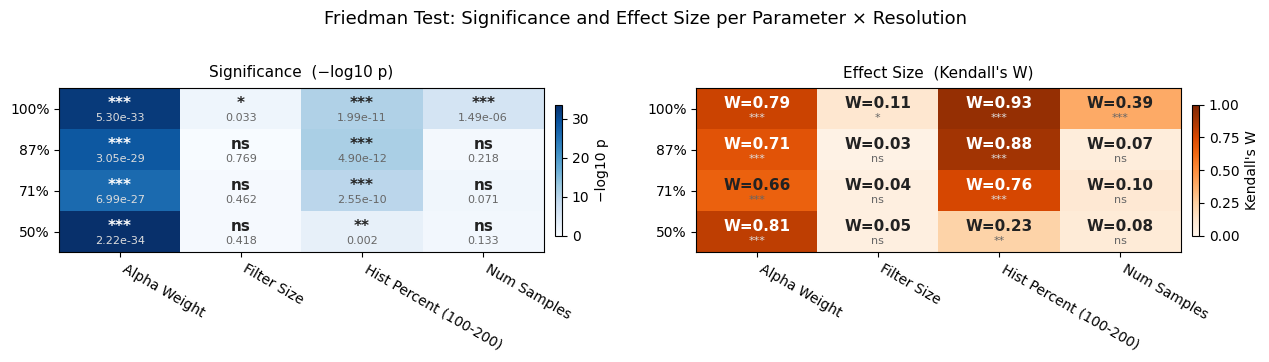

In [56]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from scipy.stats import friedmanchisquare

# ── Compute Friedman + Kendall's W ───────────────────────────────────────────
friedman_results = []
for param in PARAMS:
    for res in [100,87,71,50]:
        sub = df[(df['parameter'] == param) & (df['resolution'] == res)]
        pivot = sub.pivot_table(index='scene', columns='value', values='score').dropna()
        if pivot.shape[0] < 3 or pivot.shape[1] < 3:
            continue
        stat, p = friedmanchisquare(*[pivot[col].values for col in pivot.columns])
        n_scenes, n_levels = pivot.shape[0], pivot.shape[1]
        W = stat / (n_scenes * (n_levels - 1))
        friedman_results.append({
            'parameter':  param,
            'resolution': f'{res}%',
            'statistic':  round(stat, 3),
            'p_value':    p,
            'p_display':  f'{p:.2e}' if p < 0.001 else f'{p:.3f}',
            'sig':        '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns',
            'kendalls_W': round(W, 3),
            'W_display':  f'W={W:.2f}',
        })

fdf = pd.DataFrame(friedman_results)
fdf['param_label'] = fdf['parameter'].map(param_labels)
fdf['neg_log10_p'] = fdf['p_value'].apply(lambda p: -np.log10(p) if p > 0 else 0)
max_nlp = fdf['neg_log10_p'].max()

param_order = ['Alpha Weight', 'Filter Size', 'Hist Percent (100-200)', 'Num Samples']
res_order   = ['100%', '87%', '71%', '50%']

# ── Pivot into 2D grids ───────────────────────────────────────────────────────
def make_grid(fdf, value_col):
    return fdf.pivot_table(index='resolution', columns='param_label',
                           values=value_col, aggfunc='first').reindex(
                               index=res_order, columns=param_order)

grid_p   = make_grid(fdf, 'neg_log10_p')
grid_W   = make_grid(fdf, 'kendalls_W')
grid_sig = make_grid(fdf, 'sig')
grid_pd  = make_grid(fdf, 'p_display')
grid_Wd  = make_grid(fdf, 'W_display')

nrows, ncols = len(res_order), len(param_order)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.5))
fig.suptitle('Friedman Test: Significance and Effect Size per Parameter × Resolution',
             fontsize=13, y=1.02)

def draw_heatmap(ax, grid_vals, grid_text1, grid_text2,
                 cmap, vmin, vmax, title, cbar_label):
    data = grid_vals.values.astype(float)
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')

    cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label(cbar_label, fontsize=10)

    ax.set_xticks(range(ncols))
    ax.set_xticklabels(param_order, fontsize=10, rotation=-30, ha='left')
    ax.set_yticks(range(nrows))
    ax.set_yticklabels(res_order, fontsize=10)
    ax.set_title(title, fontsize=11, pad=8)

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap_obj = plt.get_cmap(cmap)

    for i in range(nrows):
        for j in range(ncols):
            val = data[i, j]
            # luminance of the background cell
            rgba = cmap_obj(norm(val))
            lum  = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
            fg   = 'white' if lum < 0.5 else '#222222'
            fg2  = '#dddddd' if lum < 0.5 else '#666666'

            t1 = grid_text1.iloc[i, j]
            t2 = grid_text2.iloc[i, j]
            ax.text(j, i - 0.12, str(t1), ha='center', va='center',
                    fontsize=11, fontweight='bold', color=fg)
            ax.text(j, i + 0.22, str(t2), ha='center', va='center',
                    fontsize=8, color=fg2)

# p-value heatmap
draw_heatmap(ax1,
             grid_vals=grid_p,
             grid_text1=grid_sig,
             grid_text2=grid_pd,
             cmap='Blues',
             vmin=0, vmax=max_nlp,
             title='Significance  (−log10 p)',
             cbar_label='−log10 p')

# Kendall's W heatmap
draw_heatmap(ax2,
             grid_vals=grid_W,
             grid_text1=grid_Wd,
             grid_text2=grid_sig,
             cmap='Oranges',
             vmin=0, vmax=1,
             title="Effect Size  (Kendall's W)",
             cbar_label="Kendall's W")

plt.tight_layout()
plt.savefig('friedman_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [60]:
# ── Cell: Statistical Tests + Altair Heatmaps ─────────────────────────────
#
# Centering (already applied in df['score_centered'] by cell 1):
#   For each (scene s, parameter θ, resolution r):
#     baseline  = mean of score over shared values V_{θ,r}
#                 (values present for ALL scenes in that slice)
#     q̃_{s,θ,r,v} = q_{s,θ,r,v} - baseline
#
# Tests 1–3 use df['score_centered']; test 4 (LME) uses df['score'] (raw).
# ──────────────────────────────────────────────────────────────────────────

import warnings
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM
import altair as alt

warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════════════
# 1.  TEST FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════

def _normalise(s: pd.Series) -> pd.Series:
    lo, hi = s.min(), s.max()
    return pd.Series(np.zeros(len(s)), index=s.index) if hi == lo else (s - lo) / (hi - lo)


def test_rm_anova(grp: pd.DataFrame) -> dict:
    """
    OLS on centered scores, factor = C(value), Type-II F-test.
    Centering already removes between-scene variance, so no scene term needed.
    """
    try:
        model = ols("score_centered ~ C(value)", data=grp).fit()
        tbl   = sm.stats.anova_lm(model, typ=2)
        row   = tbl.loc["C(value)"]
        return dict(F=float(row["F"]),
                    df_num=int(row["df"]),
                    df_den=int(tbl.loc["Residual", "df"]),
                    p=float(row["PR(>F)"]))
    except Exception as e:
        return dict(F=np.nan, df_num=np.nan, df_den=np.nan, p=np.nan, error=str(e))


def test_spearman(grp: pd.DataFrame) -> dict:
    """
    Spearman ρ between parameter value and centered score,
    pooling all (scene × value) pairs in the (parameter, resolution) slice.
    """
    try:
        rho, p = stats.spearmanr(grp["value"], grp["score_centered"])
        return dict(rho=float(rho), p=float(p), n=len(grp))
    except Exception as e:
        return dict(rho=np.nan, p=np.nan, n=len(grp), error=str(e))


def test_kruskal(grp: pd.DataFrame) -> dict:
    """
    Kruskal-Wallis H on centered scores, grouped by value level.
    Robust to missing value levels across scenes (no balance requirement).
    """
    try:
        groups = [g["score_centered"].values for _, g in grp.groupby("value")]
        if len(groups) < 2:
            raise ValueError("Need ≥ 2 value levels.")
        H, p = stats.kruskal(*groups)
        return dict(H=float(H), df=len(groups) - 1, p=float(p))
    except Exception as e:
        return dict(H=np.nan, df=np.nan, p=np.nan, error=str(e))


def test_lme(grp: pd.DataFrame) -> dict:
    """
    LME on RAW scores: score ~ value_norm [+ value_norm²] + (1|scene).
    Fits linear and quadratic models (REML=False); selects via LRT (α=0.05).
    Reports z-test p-value on the linear coefficient of the winning model.
    """
    try:
        g = grp.copy()
        g["value_norm"]  = _normalise(g["value"])
        g["value_norm2"] = g["value_norm"] ** 2

        fit_lin  = MixedLM.from_formula("score ~ value_norm",
                                         data=g, groups=g["scene"]).fit(reml=False, method="lbfgs")
        fit_quad = MixedLM.from_formula("score ~ value_norm + value_norm2",
                                         data=g, groups=g["scene"]).fit(reml=False, method="lbfgs")

        lr_stat  = 2.0 * (fit_quad.llf - fit_lin.llf)
        lr_p     = float(stats.chi2.sf(lr_stat, df=1))
        use_quad = lr_p < 0.05
        best     = fit_quad if use_quad else fit_lin

        return dict(
            coef_linear    = float(best.params["value_norm"]),
            coef_quadratic = float(best.params.get("value_norm2", np.nan)),
            p              = float(best.pvalues["value_norm"]),
            lr_p           = lr_p,
            model          = "quadratic" if use_quad else "linear",
        )
    except Exception as e:
        return dict(coef_linear=np.nan, coef_quadratic=np.nan,
                    p=np.nan, lr_p=np.nan, model="error", error=str(e))


# ══════════════════════════════════════════════════════════════════════════
# 2.  RUN ALL TESTS
# ══════════════════════════════════════════════════════════════════════════

TEST_FNS = dict(rm_anova=test_rm_anova, spearman=test_spearman,
                kruskal=test_kruskal,   lme=test_lme)

rows = []
for (param, res), sdf in df.groupby(["parameter", "resolution"]):
    row = dict(parameter=param, resolution=res)
    for name, fn in TEST_FNS.items():
        for k, v in fn(sdf).items():
            row[f"{name}_{k}"] = v
    rows.append(row)

results_df = (pd.DataFrame(rows)
              .sort_values(["parameter", "resolution"])
              .reset_index(drop=True))

# ── quick console summary ──────────────────────────────────────────────────
_cols = ["parameter", "resolution",
         "rm_anova_F", "rm_anova_p",
         "spearman_rho", "spearman_p",
         "kruskal_H", "kruskal_p",
         "lme_coef_linear", "lme_p", "lme_model"]
print(results_df[_cols].to_string(index=False, float_format=lambda x: f"{x:.4f}"))


# ══════════════════════════════════════════════════════════════════════════
# 3.  ALTAIR HEATMAPS  (−log10 p, one panel per test)
# ══════════════════════════════════════════════════════════════════════════

def sig_stars(p):
    if   p < 0.001: return "***"
    elif p < 0.01:  return "**"
    elif p < 0.05:  return "*"
    else:           return ""

# ── build long-form plot table ─────────────────────────────────────────────
plot_specs = [
    ("rm_anova",  "rm_anova_p",  "rm-ANOVA",  "F",   "rm_anova_F"),
    ("spearman",  "spearman_p",  "Spearman",  "ρ",   "spearman_rho"),
    ("kruskal",   "kruskal_p",   "Kruskal-Wallis", "H", "kruskal_H"),
    ("lme",       "lme_p",       "LME",       "β",   "lme_coef_linear"),
]

RESOLUTION_ORDER = ["100%", "87%", "71%", "50%"]   # descending on Y
PARAM_LABELS     = {"alpha_weight": "α weight",
                    "filter_size":  "filter size",
                    "hist_percent": "hist %",
                    "num_samples":  "num samples"}

plot_rows = []
for _, r in results_df.iterrows():
    for test_key, p_col, label, stat_sym, stat_col in plot_specs:
        p_val   = r.get(p_col,   np.nan)
        stat_v  = r.get(stat_col, np.nan)
        neg_log = -np.log10(p_val) if (p_val is not None and p_val > 0 and not np.isnan(p_val)) else 0.0
        stars   = sig_stars(p_val) if not np.isnan(p_val) else ""
        plot_rows.append(dict(
            test        = label,
            parameter   = PARAM_LABELS.get(r["parameter"], r["parameter"]),
            resolution  = f"{r['resolution']}%",
            neg_log_p   = neg_log,
            p_val       = p_val,
            stat_val    = stat_v,
            stat_sym    = stat_sym,
            stars       = stars,
        ))

plot_df = pd.DataFrame(plot_rows)

# ── colour scale anchored at significance threshold ────────────────────────
thresh  = -np.log10(0.05)          # ≈ 1.301
max_nlp = plot_df["neg_log_p"].replace([np.inf], np.nan).max()
clamp   = min(max_nlp * 1.05, 10)  # cap colour range at 10 for readability

color_scale = alt.Scale(
    domain=[0, thresh, clamp],
    range=["#f0f0f0", "#fdcc8a", "#b30000"],
)

# ── shared axis configuration ──────────────────────────────────────────────
base = (alt.Chart(plot_df)
    .transform_filter(alt.datum.neg_log_p >= 0)
    .encode(
        x=alt.X("parameter:O",
                sort=list(PARAM_LABELS.values()),
                axis=alt.Axis(title=None, labelAngle=-25)),
        y=alt.Y("resolution:O",
                sort=RESOLUTION_ORDER,
                axis=alt.Axis(title="Resolution")),
    )
)

def make_panel(test_label: str) -> alt.Chart:
    filtered = base.transform_filter(alt.datum.test == test_label)

    heatmap = filtered.mark_rect().encode(
        color=alt.Color("neg_log_p:Q",
                        scale=color_scale,
                        legend=alt.Legend(title="-log₁₀(p)",
                                          orient="right",
                                          gradientLength=120)),
        tooltip=[
            alt.Tooltip("parameter:O",  title="Parameter"),
            alt.Tooltip("resolution:O", title="Resolution"),
            alt.Tooltip("p_val:Q",      title="p-value",   format=".4f"),
            alt.Tooltip("neg_log_p:Q",  title="-log₁₀(p)", format=".2f"),
            alt.Tooltip("stat_val:Q",   title="Statistic", format=".3f"),
        ],
    )

    # Text colour: white when cell is dark (neg_log_p above midpoint), else dark grey
    WHITE_THRESH = (thresh + clamp) / 2
    text_color = alt.condition(
        alt.datum.neg_log_p > WHITE_THRESH,
        alt.value("white"),
        alt.value("#222222"),
    )

    # significance stars overlaid as text
    stars_layer = filtered.mark_text(
        fontSize=13, fontWeight="bold", dy=6
    ).encode(
        text="stars:N",
        color=text_color,
    )

    # stat value as small text above stars
    stat_layer = filtered.mark_text(
        fontSize=9, dy=-5
    ).encode(
        text=alt.condition(
            alt.datum.stat_val != None,
            alt.Text("stat_val:Q", format=".2f"),
            alt.value("")
        ),
        color=text_color,
    )

    return (heatmap + stars_layer + stat_layer).properties(
        title=alt.TitleParams(test_label, fontSize=13, fontWeight="bold", anchor="middle"),
        width=200,
        height=130,
    )

panels = [make_panel(label) for _, _, label, _, _ in plot_specs]

chart = (
    alt.hconcat(*panels, spacing=18)
    .properties(
        title=alt.TitleParams(
            "CGVQM Statistical Tests — −log₁₀(p) per (parameter × resolution)",
            fontSize=15, anchor="middle", dy=-6,
        )
    )
    .configure_view(strokeWidth=0)
    .configure_axis(labelFontSize=11, titleFontSize=11)
    .configure_title(fontSize=15)
)

chart

   parameter  resolution  rm_anova_F  rm_anova_p  spearman_rho  spearman_p  kruskal_H  kruskal_p  lme_coef_linear  lme_p lme_model
alpha_weight          50     13.9516      0.0000       -0.5445      0.0000   163.0611     0.0000           4.6771 0.0070 quadratic
alpha_weight          71     12.3025      0.0000       -0.0208      0.7423   123.3608     0.0000           7.7194 0.0000 quadratic
alpha_weight          87     16.1624      0.0000        0.4117      0.0000   141.7381     0.0000           7.8853 0.0000 quadratic
alpha_weight         100     16.3141      0.0000        0.5813      0.0000   160.5439     0.0000           7.7362 0.0000 quadratic
 filter_size          50      0.5025      0.8056        0.0545      0.5135     2.4931     0.8692           0.0114 0.6143    linear
 filter_size          71      0.1581      0.9871        0.0467      0.5744     1.0910     0.9819           0.0127 0.6229    linear
 filter_size          87      0.0686      0.9987        0.0484      0.5603     2.43

alt.HConcatChart(...)

In [68]:
# ── Cell: Statistical Tests — Global Demeaning ────────────────────────────
#
# Centering strategy:
#   q̃ = q - mean_s + mean_grand
#
#   mean_s     = mean of ALL scores for scene s (across all params, res, values)
#   mean_grand = mean of ALL scores across the entire dataset
#
#   This removes between-scene bias while preserving the original score scale.
#
# Tests 1–3 use q̃; LME uses raw scores with scene as a random intercept.
# ──────────────────────────────────────────────────────────────────────────

import warnings
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM
import altair as alt

warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════════════
# 1.  COMPUTE GLOBAL DEMEANING
# ══════════════════════════════════════════════════════════════════════════

grand_mean  = df["score"].mean()
scene_means = df.groupby("scene")["score"].mean()

df_g = df.copy()
df_g["score_c"] = (df_g["score"]
                   - df_g["scene"].map(scene_means)
                   + grand_mean)


# ══════════════════════════════════════════════════════════════════════════
# 2.  TEST FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════

def _normalise(s: pd.Series) -> pd.Series:
    lo, hi = s.min(), s.max()
    return pd.Series(np.zeros(len(s)), index=s.index) if hi == lo \
           else (s - lo) / (hi - lo)


def test_rm_anova(grp: pd.DataFrame) -> dict:
    try:
        model = ols("score_c ~ C(value)", data=grp).fit()
        tbl   = sm.stats.anova_lm(model, typ=2)
        row   = tbl.loc["C(value)"]
        return dict(F=float(row["F"]),
                    df_num=int(row["df"]),
                    df_den=int(tbl.loc["Residual", "df"]),
                    p=float(row["PR(>F)"]))
    except Exception as e:
        return dict(F=np.nan, df_num=np.nan, df_den=np.nan, p=np.nan, error=str(e))


def test_spearman(grp: pd.DataFrame) -> dict:
    try:
        rho, p = stats.spearmanr(grp["value"], grp["score_c"])
        return dict(rho=float(rho), p=float(p), n=len(grp))
    except Exception as e:
        return dict(rho=np.nan, p=np.nan, n=len(grp), error=str(e))


def test_kruskal(grp: pd.DataFrame) -> dict:
    try:
        groups = [g["score_c"].values for _, g in grp.groupby("value")]
        if len(groups) < 2:
            raise ValueError("Need ≥ 2 value levels.")
        H, p = stats.kruskal(*groups)
        return dict(H=float(H), df=len(groups) - 1, p=float(p))
    except Exception as e:
        return dict(H=np.nan, df=np.nan, p=np.nan, error=str(e))


def test_lme(grp: pd.DataFrame) -> dict:
    try:
        g = grp.copy()
        g["value_norm"]  = _normalise(g["value"])
        g["value_norm2"] = g["value_norm"] ** 2

        fit_lin  = MixedLM.from_formula("score ~ value_norm",
                       data=g, groups=g["scene"]).fit(reml=False, method="lbfgs")
        fit_quad = MixedLM.from_formula("score ~ value_norm + value_norm2",
                       data=g, groups=g["scene"]).fit(reml=False, method="lbfgs")

        lr_stat  = 2.0 * (fit_quad.llf - fit_lin.llf)
        lr_p     = float(stats.chi2.sf(lr_stat, df=1))
        use_quad = lr_p < 0.05
        best     = fit_quad if use_quad else fit_lin

        return dict(
            coef_linear    = float(best.params["value_norm"]),
            coef_quadratic = float(best.params.get("value_norm2", np.nan)),
            p              = float(best.pvalues["value_norm"]),
            lr_p           = lr_p,
            model          = "quadratic" if use_quad else "linear",
        )
    except Exception as e:
        return dict(coef_linear=np.nan, coef_quadratic=np.nan,
                    p=np.nan, lr_p=np.nan, model="error", error=str(e))


# ══════════════════════════════════════════════════════════════════════════
# 3.  RUN ALL TESTS
# ══════════════════════════════════════════════════════════════════════════

TEST_FNS = dict(rm_anova=test_rm_anova, spearman=test_spearman,
                kruskal=test_kruskal,   lme=test_lme)

rows = []
for (param, res), sdf in df_g.groupby(["parameter", "resolution"]):
    row = dict(parameter=param, resolution=res)
    for name, fn in TEST_FNS.items():
        for k, v in fn(sdf).items():
            row[f"{name}_{k}"] = v
    rows.append(row)

results_global = (pd.DataFrame(rows)
                  .sort_values(["parameter", "resolution"])
                  .reset_index(drop=True))

_cols = ["parameter", "resolution",
         "rm_anova_F", "rm_anova_p",
         "spearman_rho", "spearman_p",
         "kruskal_H", "kruskal_p",
         "lme_coef_linear", "lme_p", "lme_model"]
print(results_global[_cols].to_string(index=False, float_format=lambda x: f"{x:.4f}"))


# ══════════════════════════════════════════════════════════════════════════
# 4.  ALTAIR HEATMAP
# ══════════════════════════════════════════════════════════════════════════

def sig_stars(p):
    if   p < 0.001: return "***"
    elif p < 0.01:  return "**"
    elif p < 0.05:  return "*"
    else:           return ""

PLOT_SPECS = [
    ("rm_anova", "rm_anova_p",  "rm-ANOVA",       "F", "rm_anova_F"),
    ("spearman", "spearman_p",  "Spearman",        "ρ", "spearman_rho"),
    ("kruskal",  "kruskal_p",   "Kruskal-Wallis",  "H", "kruskal_H"),
    ("lme",      "lme_p",       "LME",             "β", "lme_coef_linear"),
]

RESOLUTION_ORDER = ["100%", "87%", "71%", "50%"]
PARAM_LABELS     = {"alpha_weight": "α weight",
                    "filter_size":  "filter size",
                    "hist_percent": "hist %",
                    "num_samples":  "num samples"}

plot_rows = []
for _, r in results_global.iterrows():
    for _, p_col, label, stat_sym, stat_col in PLOT_SPECS:
        p_val   = r.get(p_col,    np.nan)
        stat_v  = r.get(stat_col, np.nan)
        neg_log = (-np.log10(p_val)
                   if (p_val is not None and p_val > 0 and not np.isnan(p_val))
                   else 0.0)
        plot_rows.append(dict(
            test       = label,
            parameter  = PARAM_LABELS.get(r["parameter"], r["parameter"]),
            resolution = f"{r['resolution']}%",
            neg_log_p  = neg_log,
            p_val      = p_val,
            stat_val   = stat_v,
            stars      = sig_stars(p_val) if not np.isnan(p_val) else "",
        ))

plot_df = pd.DataFrame(plot_rows)

thresh  = -np.log10(0.05)
max_nlp = plot_df["neg_log_p"].replace([np.inf], np.nan).max()
clamp   = min(max_nlp * 1.05, 10)

color_scale = alt.Scale(
    domain=[0, thresh, clamp],
    range=["#f0f0f0", "#fdcc8a", "#b30000"],
)
WHITE_THRESH = (thresh + clamp) / 2


def make_panel(test_label: str) -> alt.Chart:
    base = (alt.Chart(plot_df)
        .transform_filter(alt.datum.test == test_label)
        .encode(
            x=alt.X("parameter:O",
                    sort=list(PARAM_LABELS.values()),
                    axis=alt.Axis(title=None, labelAngle=-25)),
            y=alt.Y("resolution:O",
                    sort=RESOLUTION_ORDER,
                    axis=alt.Axis(title="Resolution")),
        )
    )

    heatmap = base.mark_rect().encode(
        color=alt.Color("neg_log_p:Q",
                        scale=color_scale,
                        legend=alt.Legend(title="-log₁₀(p)",
                                          orient="right",
                                          gradientLength=120)),
        tooltip=[
            alt.Tooltip("parameter:O",  title="Parameter"),
            alt.Tooltip("resolution:O", title="Resolution"),
            alt.Tooltip("p_val:Q",      title="p-value",   format=".4f"),
            alt.Tooltip("neg_log_p:Q",  title="-log₁₀(p)", format=".2f"),
            alt.Tooltip("stat_val:Q",   title="Statistic", format=".3f"),
        ],
    )

    text_color = alt.condition(
        alt.datum.neg_log_p > WHITE_THRESH,
        alt.value("white"),
        alt.value("#222222"),
    )

    stars_layer = base.mark_text(fontSize=13, fontWeight="bold", dy=6).encode(
        text="stars:N", color=text_color)

    stat_layer = base.mark_text(fontSize=9, dy=-5).encode(
        text=alt.condition(
            alt.datum.stat_val != None,
            alt.Text("stat_val:Q", format=".2f"),
            alt.value(""),
        ),
        color=text_color,
    )

    return (heatmap + stars_layer + stat_layer).properties(
        title=alt.TitleParams(test_label, fontSize=13,
                              fontWeight="bold", anchor="middle"),
        width=200, height=130,
    )


panels = [make_panel(label) for _, _, label, _, _ in PLOT_SPECS]

chart = (
    alt.hconcat(*panels, spacing=18)
    .properties(
        title=alt.TitleParams(
            [
                "CGVQM Statistical Tests — −log₁₀(p) per (parameter × resolution)",
                "Centering: q̃ = q − scene mean + grand mean",
            ],
            fontSize=14, anchor="middle", dy=-6,
        )
    )
    .configure_view(strokeWidth=0)
    .configure_axis(labelFontSize=11, titleFontSize=11)
    .configure_title(fontSize=14)
)

chart

   parameter  resolution  rm_anova_F  rm_anova_p  spearman_rho  spearman_p  kruskal_H  kruskal_p  lme_coef_linear  lme_p lme_model
alpha_weight          50      4.9098      0.0000       -0.2481      0.0001    39.3025     0.0000           4.6771 0.0070 quadratic
alpha_weight          71     10.5750      0.0000        0.0246      0.6975   109.9805     0.0000           7.7194 0.0000 quadratic
alpha_weight          87      5.6175      0.0000        0.3088      0.0000    59.4336     0.0000           7.8853 0.0000 quadratic
alpha_weight         100      3.8742      0.0000        0.3146      0.0000    40.8626     0.0000           7.7362 0.0000 quadratic
 filter_size          50      0.0079      1.0000        0.0034      0.9674     0.1038     1.0000           0.0114 0.6143    linear
 filter_size          71      0.0057      1.0000        0.0085      0.9190     0.0460     1.0000           0.0127 0.6229    linear
 filter_size          87      0.0017      1.0000        0.0051      0.9508     0.04

alt.HConcatChart(...)

In [69]:
# ── Cell: Statistical Tests — No Demeaning ────────────────────────────────
#
# Centering strategy: none.
#   score_c = raw score q_{s,θ,r,v}
#
# Tests 1–3 operate directly on raw scores.
# LME also uses raw scores (unchanged — scene random intercept handles bias).
# ──────────────────────────────────────────────────────────────────────────

import warnings
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM
import altair as alt

warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════════════
# 1.  NO DEMEANING — score_c is just the raw score
# ══════════════════════════════════════════════════════════════════════════

df_r = df.copy()
df_r["score_c"] = df_r["score"]


# ══════════════════════════════════════════════════════════════════════════
# 2.  TEST FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════

def _normalise(s: pd.Series) -> pd.Series:
    lo, hi = s.min(), s.max()
    return pd.Series(np.zeros(len(s)), index=s.index) if hi == lo \
           else (s - lo) / (hi - lo)


def test_rm_anova(grp: pd.DataFrame) -> dict:
    try:
        model = ols("score_c ~ C(value)", data=grp).fit()
        tbl   = sm.stats.anova_lm(model, typ=2)
        row   = tbl.loc["C(value)"]
        return dict(F=float(row["F"]),
                    df_num=int(row["df"]),
                    df_den=int(tbl.loc["Residual", "df"]),
                    p=float(row["PR(>F)"]))
    except Exception as e:
        return dict(F=np.nan, df_num=np.nan, df_den=np.nan, p=np.nan, error=str(e))


def test_spearman(grp: pd.DataFrame) -> dict:
    try:
        rho, p = stats.spearmanr(grp["value"], grp["score_c"])
        return dict(rho=float(rho), p=float(p), n=len(grp))
    except Exception as e:
        return dict(rho=np.nan, p=np.nan, n=len(grp), error=str(e))


def test_kruskal(grp: pd.DataFrame) -> dict:
    try:
        groups = [g["score_c"].values for _, g in grp.groupby("value")]
        if len(groups) < 2:
            raise ValueError("Need ≥ 2 value levels.")
        H, p = stats.kruskal(*groups)
        return dict(H=float(H), df=len(groups) - 1, p=float(p))
    except Exception as e:
        return dict(H=np.nan, df=np.nan, p=np.nan, error=str(e))


def test_lme(grp: pd.DataFrame) -> dict:
    try:
        g = grp.copy()
        g["value_norm"]  = _normalise(g["value"])
        g["value_norm2"] = g["value_norm"] ** 2

        fit_lin  = MixedLM.from_formula("score ~ value_norm",
                       data=g, groups=g["scene"]).fit(reml=False, method="lbfgs")
        fit_quad = MixedLM.from_formula("score ~ value_norm + value_norm2",
                       data=g, groups=g["scene"]).fit(reml=False, method="lbfgs")

        lr_stat  = 2.0 * (fit_quad.llf - fit_lin.llf)
        lr_p     = float(stats.chi2.sf(lr_stat, df=1))
        use_quad = lr_p < 0.05
        best     = fit_quad if use_quad else fit_lin

        return dict(
            coef_linear    = float(best.params["value_norm"]),
            coef_quadratic = float(best.params.get("value_norm2", np.nan)),
            p              = float(best.pvalues["value_norm"]),
            lr_p           = lr_p,
            model          = "quadratic" if use_quad else "linear",
        )
    except Exception as e:
        return dict(coef_linear=np.nan, coef_quadratic=np.nan,
                    p=np.nan, lr_p=np.nan, model="error", error=str(e))


# ══════════════════════════════════════════════════════════════════════════
# 3.  RUN ALL TESTS
# ══════════════════════════════════════════════════════════════════════════

TEST_FNS = dict(rm_anova=test_rm_anova, spearman=test_spearman,
                kruskal=test_kruskal,   lme=test_lme)

rows = []
for (param, res), sdf in df_r.groupby(["parameter", "resolution"]):
    row = dict(parameter=param, resolution=res)
    for name, fn in TEST_FNS.items():
        for k, v in fn(sdf).items():
            row[f"{name}_{k}"] = v
    rows.append(row)

results_raw = (pd.DataFrame(rows)
               .sort_values(["parameter", "resolution"])
               .reset_index(drop=True))

_cols = ["parameter", "resolution",
         "rm_anova_F", "rm_anova_p",
         "spearman_rho", "spearman_p",
         "kruskal_H", "kruskal_p",
         "lme_coef_linear", "lme_p", "lme_model"]
print(results_raw[_cols].to_string(index=False, float_format=lambda x: f"{x:.4f}"))


# ══════════════════════════════════════════════════════════════════════════
# 4.  ALTAIR HEATMAP
# ══════════════════════════════════════════════════════════════════════════

def sig_stars(p):
    if   p < 0.001: return "***"
    elif p < 0.01:  return "**"
    elif p < 0.05:  return "*"
    else:           return ""

PLOT_SPECS = [
    ("rm_anova", "rm_anova_p",  "rm-ANOVA",       "F", "rm_anova_F"),
    ("spearman", "spearman_p",  "Spearman",        "ρ", "spearman_rho"),
    ("kruskal",  "kruskal_p",   "Kruskal-Wallis",  "H", "kruskal_H"),
    ("lme",      "lme_p",       "LME",             "β", "lme_coef_linear"),
]

RESOLUTION_ORDER = ["100%", "87%", "71%", "50%"]
PARAM_LABELS     = {"alpha_weight": "α weight",
                    "filter_size":  "filter size",
                    "hist_percent": "hist %",
                    "num_samples":  "num samples"}

plot_rows = []
for _, r in results_raw.iterrows():
    for _, p_col, label, stat_sym, stat_col in PLOT_SPECS:
        p_val   = r.get(p_col,    np.nan)
        stat_v  = r.get(stat_col, np.nan)
        neg_log = (-np.log10(p_val)
                   if (p_val is not None and p_val > 0 and not np.isnan(p_val))
                   else 0.0)
        plot_rows.append(dict(
            test       = label,
            parameter  = PARAM_LABELS.get(r["parameter"], r["parameter"]),
            resolution = f"{r['resolution']}%",
            neg_log_p  = neg_log,
            p_val      = p_val,
            stat_val   = stat_v,
            stars      = sig_stars(p_val) if not np.isnan(p_val) else "",
        ))

plot_df = pd.DataFrame(plot_rows)

thresh  = -np.log10(0.05)
max_nlp = plot_df["neg_log_p"].replace([np.inf], np.nan).max()
clamp   = min(max_nlp * 1.05, 10)

color_scale = alt.Scale(
    domain=[0, thresh, clamp],
    range=["#f0f0f0", "#fdcc8a", "#b30000"],
)
WHITE_THRESH = (thresh + clamp) / 2


def make_panel(test_label: str) -> alt.Chart:
    base = (alt.Chart(plot_df)
        .transform_filter(alt.datum.test == test_label)
        .encode(
            x=alt.X("parameter:O",
                    sort=list(PARAM_LABELS.values()),
                    axis=alt.Axis(title=None, labelAngle=-25)),
            y=alt.Y("resolution:O",
                    sort=RESOLUTION_ORDER,
                    axis=alt.Axis(title="Resolution")),
        )
    )

    heatmap = base.mark_rect().encode(
        color=alt.Color("neg_log_p:Q",
                        scale=color_scale,
                        legend=alt.Legend(title="-log₁₀(p)",
                                          orient="right",
                                          gradientLength=120)),
        tooltip=[
            alt.Tooltip("parameter:O",  title="Parameter"),
            alt.Tooltip("resolution:O", title="Resolution"),
            alt.Tooltip("p_val:Q",      title="p-value",   format=".4f"),
            alt.Tooltip("neg_log_p:Q",  title="-log₁₀(p)", format=".2f"),
            alt.Tooltip("stat_val:Q",   title="Statistic", format=".3f"),
        ],
    )

    text_color = alt.condition(
        alt.datum.neg_log_p > WHITE_THRESH,
        alt.value("white"),
        alt.value("#222222"),
    )

    stars_layer = base.mark_text(fontSize=13, fontWeight="bold", dy=6).encode(
        text="stars:N", color=text_color)

    stat_layer = base.mark_text(fontSize=9, dy=-5).encode(
        text=alt.condition(
            alt.datum.stat_val != None,
            alt.Text("stat_val:Q", format=".2f"),
            alt.value(""),
        ),
        color=text_color,
    )

    return (heatmap + stars_layer + stat_layer).properties(
        title=alt.TitleParams(test_label, fontSize=13,
                              fontWeight="bold", anchor="middle"),
        width=200, height=130,
    )


panels = [make_panel(label) for _, _, label, _, _ in PLOT_SPECS]

chart = (
    alt.hconcat(*panels, spacing=18)
    .properties(
        title=alt.TitleParams(
            [
                "CGVQM Statistical Tests — −log₁₀(p) per (parameter × resolution)",
                "Centering: none (raw scores)",
            ],
            fontSize=14, anchor="middle", dy=-6,
        )
    )
    .configure_view(strokeWidth=0)
    .configure_axis(labelFontSize=11, titleFontSize=11)
    .configure_title(fontSize=14)
)

chart

   parameter  resolution  rm_anova_F  rm_anova_p  spearman_rho  spearman_p  kruskal_H  kruskal_p  lme_coef_linear  lme_p lme_model
alpha_weight          50      0.9945      0.4520       -0.1476      0.0191    11.0941     0.4354           4.6771 0.0070 quadratic
alpha_weight          71      0.4638      0.9241       -0.0432      0.4945     6.2337     0.8573           7.7194 0.0000 quadratic
alpha_weight          87      0.5460      0.8705        0.0647      0.3064     5.9303     0.8780           7.8853 0.0000 quadratic
alpha_weight         100      0.8543      0.5860        0.1223      0.0526     8.6436     0.6547           7.7362 0.0000 quadratic
 filter_size          50      0.0502      0.9995        0.0038      0.9635     0.1369     0.9999           0.0114 0.6143    linear
 filter_size          71      0.0000      1.0000        0.0062      0.9405     0.0162     1.0000           0.0127 0.6229    linear
 filter_size          87      0.0000      1.0000        0.0026      0.9754     0.00

alt.HConcatChart(...)

In [64]:
# Quick effect size check for hist_percent
for res in [50, 71, 87, 100]:
    sdf = df[(df.parameter=="hist_percent") & (df.resolution==res)]
    group_means = sdf.groupby("value")["score_centered"].mean()
    spread = group_means.max() - group_means.min()
    overall_std = sdf["score_centered"].std()
    print(f"{res}%  mean spread across values: {spread:.3f}  std: {overall_std:.3f}  ratio: {spread/overall_std:.2f}")

50%  mean spread across values: 0.591  std: 0.686  ratio: 0.86
71%  mean spread across values: 1.241  std: 0.670  ratio: 1.85
87%  mean spread across values: 1.441  std: 0.718  ratio: 2.01
100%  mean spread across values: 1.375  std: 0.716  ratio: 1.92


In [62]:
# ── Corrected Sanity Check ─────────────────────────────────────────────────

# 1. For each (scene, parameter, resolution), compute mean of score_centered
#    over ONLY the shared values (present in ALL scenes for that param×res).
errors = []
for (param, res), sdf in df.groupby(["parameter", "resolution"]):
    n_scenes = sdf["scene"].nunique()
    shared_vals = (sdf.groupby("value")["scene"].nunique()
                     .pipe(lambda s: s[s == n_scenes].index))
    for scene, scenedf in sdf.groupby("scene"):
        mask = scenedf["value"].isin(shared_vals)
        mean_centered = scenedf.loc[mask, "score_centered"].mean()
        errors.append(dict(scene=scene, parameter=param,
                           resolution=res, mean=mean_centered))

err_df = pd.DataFrame(errors)
print("Max absolute within-group mean over shared values (should be ~0):",
      err_df["mean"].abs().max().round(8))
print("Any group with |mean| > 1e-6:",
      (err_df["mean"].abs() > 1e-6).sum(), "of", len(err_df))

# 2. Variance reduction check (unchanged — this one was fine)
print("\nRaw score std:      ", df["score"].std().round(4))
print("Centered score std: ", df["score_centered"].std().round(4))

# 3. Spot-check (unchanged — this one was fine)
scene, param, res = df["scene"].iloc[0], "alpha_weight", 100
sub = df[(df.scene==scene)&(df.parameter==param)&(df.resolution==res)]
print(f"\nSpot check — {scene}, {param}, {res}%:")
print(sub[["value","score","score_centered"]].to_string(index=False))
print("Mean of score_centered:", sub["score_centered"].mean().round(8))

Max absolute within-group mean over shared values (should be ~0): 1.50032616
Any group with |mean| > 1e-6: 61 of 336

Raw score std:       6.757
Centered score std:  1.2551

Spot check — abandoned, alpha_weight, 100%:
 value     score  score_centered
  0.01 95.590088       -0.868072
  0.02 95.765892       -0.692268
  0.04 96.069374       -0.388786
  0.06 96.245041       -0.213119
  0.10 96.611214        0.153054
  0.20 97.059326        0.601166
  0.50 97.176247        0.718087
  0.60 97.050468        0.592309
  0.70 96.873383        0.415223
  0.80 96.649338        0.191178
  0.90 96.348541       -0.109619
  1.00 96.059006       -0.399154
Mean of score_centered: 0.0


### Alpha weight: peak value distribution per resolution

In [17]:
peak_hist = alt.Chart(peaks).mark_bar(opacity=0.7).encode(
    x=alt.X('peak_value:Q', bin=alt.Bin(step=0.1), title='Peak alpha_weight value'),
    y=alt.Y('count():Q', title='Number of scenes'),
    color=alt.Color('resolution:N', scale=color_scale, sort=res_order),
    column=alt.Column('resolution:N', sort=res_order)
).properties(width=150, height=150, title='Distribution of Optimal alpha_weight Per Scene')

peak_hist

alt.Chart(...)

In [18]:
from numpy.polynomial import polynomial as P

quad_records = []

for (res), group in alpha_df.groupby('resolution'):
    # Aggregate to mean per value across scenes
    curve = group.groupby('value')['score_centered'].mean()
    x = curve.index.values
    y = curve.values

    # Fit quadratic
    coeffs = np.polyfit(x, y, 2)  # [a, b, c] for ax² + bx + c
    a, b, c = coeffs
    peak_x = -b / (2 * a)  # vertex of parabola

    # R² 
    y_pred = np.polyval(coeffs, x)
    ss_res = ((y - y_pred) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot

    quad_records.append({
        'resolution': res,
        'a (quadratic)': round(a, 4),
        'b (linear)': round(b, 4),
        'c (intercept)': round(c, 4),
        'peak_at': round(peak_x, 3),
        'R²': round(r2, 4),
        'concave_down': a < 0
    })

    # Plot fitted curve
    x_smooth = np.linspace(x.min(), x.max(), 100)
    y_smooth = np.polyval(coeffs, x_smooth)
    fit_df = pd.DataFrame({'value': x_smooth, 'fitted': y_smooth, 'resolution': res})
    quad_records_plot = fit_df if res == res_order[0] else pd.concat([quad_records_plot, fit_df])
    if res == res_order[0]:
        quad_records_plot = fit_df
    else:
        quad_records_plot = pd.concat([quad_records_plot, fit_df])

quad_summary = pd.DataFrame(quad_records)
print(quad_summary.to_string(index=False))

resolution  a (quadratic)  b (linear)  c (intercept)  peak_at     R²  concave_down
      100%        -6.8122      7.9505        -1.2195    0.584 0.9255          True
       50%       -10.1576      4.9275         1.0277    0.243 0.9501          True
       71%        -9.4751      7.9869        -0.4342    0.421 0.9023          True
       87%        -7.6278      8.1175        -1.0430    0.532 0.9205          True


###  hist_percent: per-scene Spearman r + range

In [19]:
hist_df = df[df['parameter'] == 'hist_percent'].copy()

spearman_records = []
range_records = []

for (scene, res), group in hist_df.groupby(['scene', 'resolution']):
    val_means = group.groupby('value')['score_centered'].mean()
    if len(val_means) < 3:
        continue
    r, p = stats.spearmanr(val_means.index, val_means.values)
    score_range = group.groupby('value')['score'].mean().max() - group.groupby('value')['score'].mean().min()
    spearman_records.append({'scene': scene, 'resolution': res, 'spearman_r': r, 'p_value': p})
    range_records.append({'scene': scene, 'resolution': res, 'score_range': score_range})

spearman_hist = pd.DataFrame(spearman_records)
range_hist = pd.DataFrame(range_records)
spearman_hist['resolution'] = spearman_hist['resolution'].astype(str) + '%'
range_hist['resolution'] = range_hist['resolution'].astype(str) + '%'

# Spearman r distribution
r_plot = alt.Chart(spearman_hist).mark_bar(opacity=0.7).encode(
    x=alt.X('spearman_r:Q', bin=alt.Bin(step=0.2), title='Spearman r'),
    y=alt.Y('count():Q', title='Scenes'),
    color=alt.Color('resolution:N', scale=color_scale, sort=res_order),
    column=alt.Column('resolution:N', sort=res_order)
).properties(width=130, height=150, title='hist_percent: Per-Scene Spearman r (monotonic consistency)')

# Score range distribution
range_plot = alt.Chart(range_hist).mark_bar(opacity=0.7).encode(
    x=alt.X('score_range:Q', bin=alt.Bin(step=0.5), title='Score range (pts)'),
    y=alt.Y('count():Q', title='Scenes'),
    color=alt.Color('resolution:N', scale=color_scale, sort=res_order),
    column=alt.Column('resolution:N', sort=res_order)
).properties(width=130, height=150, title='hist_percent: Per-Scene Score Range vs 5pt threshold')

# Reference line at 5 pts
threshold_line = alt.Chart(pd.DataFrame({'x': [5]})).mark_rule(
    color='red', strokeDash=[4,4]
).encode(x='x:Q')

r_plot & (range_plot + threshold_line)

TypeError: Faceted charts cannot be layered. Instead, layer the charts before faceting.

In [20]:
from scipy.stats import ttest_1samp

EQUIVALENCE_BOUND = 2.0  # points — half the 5pt perceptual threshold, conservative

tost_records = []

for param in ['filter_size', 'num_samples']:
    for (res), group in df[df['parameter'] == param].groupby('resolution'):
        # Per scene: compute range across parameter values
        scene_ranges = group.groupby('scene').apply(
            lambda s: s.groupby('value')['score'].mean().max() - s.groupby('value')['score'].mean().min()
        )
        # TOST: test that mean range is less than EQUIVALENCE_BOUND
        # H0: effect >= bound  →  reject = effect is negligible
        t_upper, p_upper = ttest_1samp(scene_ranges, EQUIVALENCE_BOUND)
        t_lower, p_lower = ttest_1samp(scene_ranges, -EQUIVALENCE_BOUND)
        tost_p = max(p_upper / 2, p_lower / 2)  # one-tailed
        tost_records.append({
            'parameter': param,
            'resolution': res,
            'mean_range': round(scene_ranges.mean(), 4),
            'std_range': round(scene_ranges.std(), 4),
            'TOST_p': round(tost_p, 6),
            'equivalent': tost_p < 0.05,
            'bound': EQUIVALENCE_BOUND
        })

tost_df = pd.DataFrame(tost_records)
print(tost_df.to_string(index=False))

  parameter  resolution  mean_range  std_range  TOST_p  equivalent  bound
filter_size          50      0.1317     0.1741     0.0        True    2.0
filter_size          71      0.1354     0.2231     0.0        True    2.0
filter_size          87      0.1530     0.2399     0.0        True    2.0
filter_size         100      0.1581     0.2483     0.0        True    2.0
num_samples          50      0.1599     0.1950     0.0        True    2.0
num_samples          71      0.1574     0.2195     0.0        True    2.0
num_samples          87      0.1769     0.2410     0.0        True    2.0
num_samples         100      0.2926     0.2565     0.0        True    2.0


/var/folders/wh/dwptv6ss1nzbsg6xw_2p4c9h0000gn/T/ipykernel_47257/4105432956.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  scene_ranges = group.groupby('scene').apply(
/var/folders/wh/dwptv6ss1nzbsg6xw_2p4c9h0000gn/T/ipykernel_47257/4105432956.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  scene_ranges = group.groupby('scene').apply(
/var/folders/wh/dwptv6ss1nzbsg6xw_2p4c9h0000gn/T/ipykernel_47257/4105432

In [21]:
flat_params = ['filter_size', 'num_samples']
agg_flat = df[df['parameter'].isin(flat_params)].groupby(
    ['parameter', 'resolution', 'value'])['score_centered'].agg(['mean','std','count']).reset_index()
agg_flat['ci95'] = 1.96 * agg_flat['std'] / np.sqrt(agg_flat['count'])
agg_flat['resolution'] = agg_flat['resolution'].astype(str) + '%'

# Equivalence band (±2 pts)
band_df = pd.DataFrame({'y': [EQUIVALENCE_BOUND], 'y2': [-EQUIVALENCE_BOUND]})
eq_band = alt.Chart(band_df).mark_rect(opacity=0.08, color='gray').encode(
    y='y2:Q', y2='y:Q'
)
eq_upper = alt.Chart(band_df).mark_rule(strokeDash=[4,4], color='gray', opacity=0.5).encode(y='y:Q')
eq_lower = alt.Chart(band_df).mark_rule(strokeDash=[4,4], color='gray', opacity=0.5).encode(y='y2:Q')

charts = []
for param in flat_params:
    sub = agg_flat[agg_flat['parameter'] == param]
    line = alt.Chart(sub).mark_line(point=True).encode(
        x=alt.X('value:Q', title=param),
        y=alt.Y('mean:Q', title='Centered CGVQM', scale=alt.Scale(domain=[-3, 3])),
        color=alt.Color('resolution:N', scale=color_scale, sort=res_order)
    )
    band = alt.Chart(sub).mark_errorband(opacity=0.15).encode(
        x='value:Q',
        y=alt.Y('mean:Q', scale=alt.Scale(domain=[-3, 3])),
        yError='ci95:Q',
        color=alt.Color('resolution:N', scale=color_scale, sort=res_order)
    )
    charts.append((eq_band + eq_upper + eq_lower + band + line).properties(
        title=param, width=300, height=220
    ))

alt.hconcat(*charts).resolve_scale(color='shared').properties(
    title=f'filter_size & num_samples: Effects Within ±{EQUIVALENCE_BOUND}pt Equivalence Band'
)

alt.HConcatChart(...)

### Statistical Tests 
The issue with using some of these tests is that they want some sort of monotonic increase--this is not what happens with alpha weight. So, they often show significance weirdly...

#### Anova Test (said everything was insignificant)

In [67]:
# Anova shows everything as insignificant...
anova_records = []

for (param, res), group in df.groupby(['parameter', 'resolution']):
    groups_by_value = [g['score'].values for _, g in group.groupby('value')]
    if len(groups_by_value) < 2:
        continue
    f_stat, p_val = stats.f_oneway(*groups_by_value)
    anova_records.append({
        'parameter': param,
        'resolution': res,
        'F': round(f_stat, 4),
        'p_value': round(p_val, 6),
        'significant': p_val < 0.05,
    })

anova_df = pd.DataFrame(anova_records)
anova_df

,parameter,resolution,F,p_value,significant
0,alpha_weight,50,0.9945,0.451983,False
1,alpha_weight,71,0.4638,0.924072,False
2,alpha_weight,87,0.5460,0.870472,False
3,alpha_weight,100,0.8543,0.585960,False
4,filter_size,50,0.0502,0.999473,False
5,filter_size,71,0.0000,1.000000,False
6,filter_size,87,0.0000,1.000000,False
7,filter_size,100,0.0029,1.000000,False
8,hist_percent,50,0.0234,0.995114,False
9,hist_percent,71,0.1846,0.906569,False


In [9]:
effect_records = []

for (param, res), group in df.groupby(['parameter', 'resolution']):
    scene_ranges = group.groupby('scene').apply(
        lambda s: s.groupby('value')['score'].mean().max() - s.groupby('value')['score'].mean().min()
    )
    effect_records.append({
        'parameter': param,
        'resolution': res,
        'mean_range': scene_ranges.mean(),
        'se_range': scene_ranges.sem()
    })

effect_df = pd.DataFrame(effect_records)
effect_df['range_label'] = effect_df['mean_range'].apply(lambda x: f'{x:.2f}')

/var/folders/wh/dwptv6ss1nzbsg6xw_2p4c9h0000gn/T/ipykernel_47257/1139419750.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  scene_ranges = group.groupby('scene').apply(
/var/folders/wh/dwptv6ss1nzbsg6xw_2p4c9h0000gn/T/ipykernel_47257/1139419750.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  scene_ranges = group.groupby('scene').apply(
/var/folders/wh/dwptv6ss1nzbsg6xw_2p4c9h0000gn/T/ipykernel_47257/113941975

In [10]:
from scipy.stats import friedmanchisquare

# ── Friedman ──────────────────────────────────────────────────────────────────
def compute_friedman(df):
    records = []
    for (param, res), group in df.groupby(['parameter', 'resolution']):
        value_counts = group.groupby('scene')['value'].nunique()
        n_values = group['value'].nunique()
        complete_scenes = value_counts[value_counts == n_values].index
        group = group[group['scene'].isin(complete_scenes)]
        if group['scene'].nunique() < 3:
            continue
        values = sorted(group['value'].unique())
        groups_by_value = [group[group['value'] == v]['score_centered'].values for v in values]
        if any(len(g) < 3 for g in groups_by_value):
            continue
        _, p = friedmanchisquare(*groups_by_value)
        records.append({'parameter': param, 'resolution': res, 'p_value': p, 'test': 'Friedman'})
    out = pd.DataFrame(records)
    out['significant'] = out['p_value'] < 0.05
    return out

# ── Kendall's W ───────────────────────────────────────────────────────────────
def kendalls_w(data):
    n, k = data.shape
    ranks = data.rank(axis=1)
    rank_sums = ranks.sum(axis=0)
    S = ((rank_sums - rank_sums.mean()) ** 2).sum()
    W = 12 * S / (n ** 2 * (k ** 3 - k))
    chi2 = n * (k - 1) * W
    p = 1 - stats.chi2.cdf(chi2, df=k - 1)
    return W, p

def compute_kendall(df):
    records = []
    for (param, res), group in df.groupby(['parameter', 'resolution']):
        value_counts = group.groupby('scene')['value'].nunique()
        n_values = group['value'].nunique()
        complete_scenes = value_counts[value_counts == n_values].index
        group = group[group['scene'].isin(complete_scenes)]
        if group['scene'].nunique() < 3:
            continue
        pivot = group.pivot_table(index='scene', columns='value', values='score_centered').dropna()
        if pivot.shape[0] < 3 or pivot.shape[1] < 2:
            continue
        W, p = kendalls_w(pivot)
        records.append({'parameter': param, 'resolution': res, 'p_value': p, 'W': round(W, 4), 'test': 'Kendall W'})
    out = pd.DataFrame(records)
    out['significant'] = out['p_value'] < 0.05
    return out

# ── Spearman ──────────────────────────────────────────────────────────────────
def compute_spearman(df):
    records = []
    for (param, res), group in df.groupby(['parameter', 'resolution']):
        scene_corrs = []
        for scene, sgroup in group.groupby('scene'):
            val_means = sgroup.groupby('value')['score_centered'].mean()
            if len(val_means) < 3:
                continue
            r, _ = stats.spearmanr(val_means.index, val_means.values)
            scene_corrs.append(r)
        if len(scene_corrs) < 3:
            continue
        t, p = stats.ttest_1samp(scene_corrs, 0)
        records.append({'parameter': param, 'resolution': res, 'mean_r': round(np.mean(scene_corrs), 4), 'p_value': round(p, 6), 'test': 'Spearman'})
    out = pd.DataFrame(records)
    out['significant'] = out['p_value'] < 0.05
    return out

In [11]:
# ── Compute all ───────────────────────────────────────────────────────────────
sig_friedman = compute_friedman(df)
sig_kendall  = compute_kendall(df)
sig_spearman = compute_spearman(df)

In [12]:
# ── Toggle this to switch tests in all downstream plots ───────────────────────
sig_df = sig_spearman   # ← change to sig_friedman, sig_kendall, or sig_spearman
print(sig_df)

       parameter  resolution  mean_r   p_value      test  significant
0   alpha_weight          50 -0.4729  0.000002  Spearman         True
1   alpha_weight          71  0.0077  0.943799  Spearman        False
2   alpha_weight          87  0.3760  0.001073  Spearman         True
3   alpha_weight         100  0.5375  0.000001  Spearman         True
4    filter_size          50  0.0876  0.262613  Spearman        False
5    filter_size          71  0.1332  0.074959  Spearman        False
6    filter_size          87  0.0545  0.445981  Spearman        False
7    filter_size         100  0.0603  0.405259  Spearman        False
8   hist_percent          50  0.0286  0.842145  Spearman        False
9   hist_percent          71  0.8667  0.000000  Spearman         True
10  hist_percent          87  0.9333  0.000000  Spearman         True
11  hist_percent         100  0.9619  0.000000  Spearman         True
12   num_samples          50  0.0857  0.369821  Spearman        False
13   num_samples    

In [13]:
summary_df = effect_df.merge(sig_df[['parameter', 'resolution', 'p_value', 'significant', 'test']], on=['parameter', 'resolution'])

base = alt.Chart(summary_df)

heatmap = base.mark_rect().encode(
    x=alt.X('resolution:O', title='Base Resolution', sort=[50, 71, 87, 100]),
    y=alt.Y('parameter:N', title='TAA Parameter'),
    color=alt.Color('mean_range:Q',
                    scale=alt.Scale(scheme='blues', domain=[0, 5]),
                    title='Mean Score Range (pts)'),
    tooltip=['parameter', 'resolution',
             alt.Tooltip('mean_range:Q', format='.3f'),
             alt.Tooltip('p_value:Q', format='.4f'),
             'significant', 'test']
)

range_text = base.mark_text(fontSize=11, dy=-6).encode(
    x=alt.X('resolution:O', sort=[50, 71, 87, 100]),
    y=alt.Y('parameter:N'),
    text='range_label:N',
    color=alt.condition(alt.datum.mean_range > 2.5, alt.value('white'), alt.value('black'))
)

sig_text = base.mark_text(fontSize=14, dy=6).encode(
    x=alt.X('resolution:O', sort=[50, 71, 87, 100]),
    y=alt.Y('parameter:N'),
    text=alt.condition(alt.datum.significant, alt.value('✱'), alt.value('')),
    color=alt.condition(alt.datum.mean_range > 2.5, alt.value('white'), alt.value('black'))
)

(heatmap + range_text + sig_text).properties(
    width=300, height=200,
    title=f'TAA Parameter Effect × Resolution ({summary_df["test"].iloc[0]})'
)

alt.LayerChart(...)

In [14]:
# Do scenes agree on the direction of the effect for each parameter?
for param in PARAMS:
    sub = df[df['parameter'] == param]
    scene_corrs = []
    for scene, sgroup in sub.groupby('scene'):
        val_means = sgroup.groupby('value')['score_centered'].mean()
        if len(val_means) < 3:
            continue
        r, _ = stats.spearmanr(val_means.index, val_means.values)
        scene_corrs.append(r)
    print(f"{param}: mean_r={np.mean(scene_corrs):.3f}, std_r={np.std(scene_corrs):.3f}, n={len(scene_corrs)}")

alpha_weight: mean_r=0.022, std_r=0.484, n=21
hist_percent: mean_r=0.705, std_r=0.477, n=21
filter_size: mean_r=0.127, std_r=0.368, n=21
num_samples: mean_r=0.410, std_r=0.516, n=21
